# Задание по библиотекам Pandas и Matplotlib

### Лабораторная работа № 4 по дисциплине «Технологии программирования»

**Вариант:** 6. **Постановка задачи:** загрузить датасет о пассажирах «Титаника», выполнить задания на анализ, обработку и визуализацию данных средствами Pandas и Matplotlib, сделать выводы.

Задания 2 и 4 содержат подпункты «в соответствии с вариантом»: варианту 6 соответствует **подпункт 1** ($(6-1)\bmod 5 + 1 = 1$); для полноты отчёта выполнены все подпункты.

**Технологии:** Python 3, NumPy, Pandas, Matplotlib, Jupyter Notebook.

Подключаем необходимые библиотеки:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Скачиваем датасет с информацией о пассажирах Титаника
(в Colab использовался `!wget`; здесь — загрузка локального файла, записанного в репозиторий, с запасным вариантом по URL):

In [2]:
import os
import urllib.request

if not os.path.exists('titanic.csv'):
    url = ('https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv')
    urllib.request.urlretrieve(url, 'titanic.csv')
print('titanic.csv готов')

titanic.csv готов


Значения колонок датасета следующие (__в соответствии с информацией с сайта__):

*    Survived Indicator (выжил пассажир или нет)
*    Passenger Class (класс)
*    Name (имя)
*    Sex (пол)
*    Age (возраст)
*    Siblings/Spouses Aboard (есть ли братья, сестры или супруг(а) на борту)
*    Parents/Children Aboard (есть ли родители или дети на борту)
*    Fare paid in £s (цена билета в фунтах стерлингов)

Загружаем данные и формируем Pandas DataFrame:

In [3]:
df = pd.read_csv('titanic.csv')
df

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500
...,...,...,...,...,...,...,...,...
882,0,2,Rev. Juozas Montvila,male,27.0,0,0,13.0000
883,1,1,Miss. Margaret Edith Graham,female,19.0,0,0,30.0000
884,0,3,Miss. Catherine Helen Johnston,female,7.0,1,2,23.4500
885,1,1,Mr. Karl Howell Behr,male,26.0,0,0,30.0000


__С использованием датафрейма нужно выполнить следующие задания__.

1. Определите, содержит ли какой-нибудь столбец датасета пропущенные значения.

In [4]:
na_counts = df.isna().sum()
na_counts

# Вывод: пропущенных значений нет ни в одном столбце, если сумма нулевая:
print('Есть пропуски:', bool(na_counts.sum() > 0))

Есть пропуски: False


2. В соответствии с вариантом, определите (вариант 6 — подпункт 1, выполнены все):

   1. Количество женщин старше 50 лет на борту.
   2. Количество пассажиров, путешествующих вторым классом вместе с родителями или детьми.
   3. Число погибших детей в возрасте до 12 лет, путешествующих первым классом.
   4. Среднее значение коэффициента выживаемости десяти пассажиров третьего класса с самыми дорогими билетами.
   5. Среднее значение цены билета пассажиров, путешествующих без родственников.

In [5]:
# 1 (вариант 6): женщины старше 50 лет
w50 = df[(df['Sex'] == 'female') & (df['Age'] > 50)]
print('1) Женщин старше 50 лет:', len(w50))

# 2: второй класс с родителями/детьми
p2 = df[(df['Pclass'] == 2) & (df['Parents/Children Aboard'] > 0)]
print('2) Пассажиры 2 класса с родителями/детьми:', len(p2))

# 3: погибшие дети до 12 лет в первом классе
kids = df[(df['Age'] < 12) & (df['Pclass'] == 1) & (df['Survived'] == 0)]
print('3) Погибшие дети (<12) 1 класса:', len(kids))

# 4: средняя выживаемость 10 самых дорогих билетов 3 класса
top10 = (df[df['Pclass'] == 3].nlargest(10, 'Fare')['Survived']
         .mean())
print('4) Средняя выживаемость топ-10 дорогих билетов 3 класса:', top10)

# 5: средняя цена билета пассажиров без родственников
alone = df[(df['Siblings/Spouses Aboard'] == 0)
           & (df['Parents/Children Aboard'] == 0)]['Fare'].mean()
print('5) Средняя цена билета пассажиров без родственников:', alone)

1) Женщин старше 50 лет: 18
2) Пассажиры 2 класса с родителями/детьми: 50
3) Погибшие дети (<12) 1 класса: 1
4) Средняя выживаемость топ-10 дорогих билетов 3 класса: 0.2
5) Средняя цена билета пассажиров без родственников: 21.32885966228893


3. Постройте диаграмму распределения значений цены билета по всем пассажирам. Проинтерпретируйте результат. Можно ли сказать, что в данных наблюдаются выбросы?

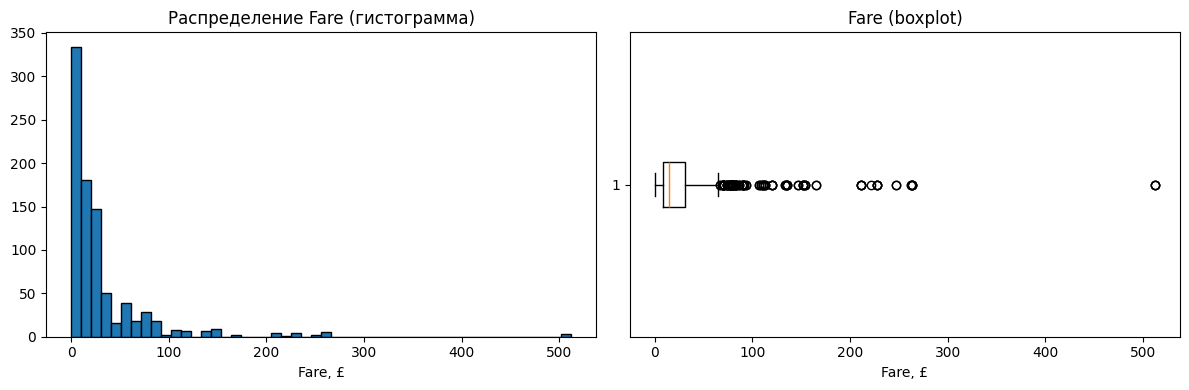

Медиана: 14.4542 | skewness: 4.78
Выбросов по правилу 1.5*IQR: 116 из 887 строк


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Fare'], bins=50, edgecolor='black')
axes[0].set_title('Распределение Fare (гистограмма)')
axes[0].set_xlabel('Fare, £')
axes[1].boxplot(df['Fare'], vert=False)
axes[1].set_title('Fare (boxplot)')
axes[1].set_xlabel('Fare, £')
plt.tight_layout()
plt.show()

q1, q3 = df['Fare'].quantile([0.25, 0.75])
iqr = q3 - q1
outliers = df[(df['Fare'] < q1 - 1.5 * iqr) |
              (df['Fare'] > q3 + 1.5 * iqr)]
print('Медиана:', df['Fare'].median(), '| skewness:',
      round(df['Fare'].skew(), 2))
print('Выбросов по правилу 1.5*IQR:', len(outliers),
      'из', len(df), 'строк')

**Интерпретация:** распределение цены билета сильно скошено вправо (skewness > 1): большинство пассажиров заплатили мало, а длинный правый хвост образован дорогими билетами первого класса. По правилу 1.5·IQR наблюдаются выраженные выбросы в области высоких значений Fare.

4. В соответствии с вариантом, определите, верны ли следующие утверждения (вариант 6 — подпункт 1, выполнены все). Приведите доказательства ответа.

  1. Чем дороже билет, тем выше вероятность выжить.
  2. Мужчинам в катастрофе выжить проще.
  3. Чем больше родственников у человека, тем выше шанс того, что он купит билет третьего класса.
  4. Если Вам больше 70 лет, то шансов выжить в катастрофе у Вас практически нет.
  5. Чем больше родственников у человека, тем выше его шанс погибнуть.

In [7]:
# 1: корреляция и выживаемость по квартилям цены
print(' corr(Fare, Survived) =', round(df['Fare'].corr(df['Survived']), 3))
fare_q = pd.qcut(df['Fare'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
print(df.groupby(fare_q, observed=True)['Survived'].mean().round(3))

# 2: выживаемость по полу
print('\n Выживаемость по полу:')
print(df.groupby('Sex')['Survived'].mean().round(3))

# 3: число родственников и доля 3 класса
rel = df['Siblings/Spouses Aboard'] + df['Parents/Children Aboard']
share3 = df.assign(rel=rel).groupby('rel').apply(
    lambda g: (g['Pclass'] == 3).mean(), include_groups=False).round(3)
print('\n Доля 3 класса по числу родственников:')
print(share3)

# 4: выживаемость пассажиров старше 70
old = df[df['Age'] > 70]
print('\n Возраст >70: пассажиров', len(old),
      ', выжили:', int(old['Survived'].sum()))

# 5: шанс погибнуть по числу родственников
perish = df.assign(rel=rel).groupby('rel').apply(
    lambda g: (g['Survived'] == 0).mean(), include_groups=False).round(3)
print('\n Шанс погибнуть по числу родственников:')
print(perish)

 corr(Fare, Survived) = 0.256
Fare
Q1    0.218
Q2    0.291
Q3    0.457
Q4    0.581
Name: Survived, dtype: float64

 Выживаемость по полу:
Sex
female    0.742
male      0.190
Name: Survived, dtype: float64

 Доля 3 класса по числу родственников:
rel
0     0.600
1     0.354
2     0.461
3     0.310
4     0.800
5     0.773
6     1.000
7     1.000
10    1.000
dtype: float64

 Возраст >70: пассажиров 5 , выжили: 1

 Шанс погибнуть по числу родственников:
rel
0     0.694
1     0.447
2     0.422
3     0.276
4     0.800
5     0.864
6     0.667
7     1.000
10    1.000
dtype: float64


**Ответы на утверждения (доказательства выше):**

1. **Верно**: корреляция Fare с фактом выживания положительна, выживаемость растёт от низших квартилей цены к высшим — богатые садились на шлюпки чаще (близко к палубе, привилегии при посадке).
2. **Неверно**: женщины выживали в разы чаще мужчин (см. groupby по Sex) — действовала стратегия «женщины и дети вперёд».
3. **Частично верно**: среди пассажиров с 4 и более родственниками почти все (доля 0.77–1.0) едут третьим классом, однако для семей из 1–3 родственников доля третьего класса ниже — связь нелинейна: большие семьи действительно путешествовали дешёвыми классами.
4. **Верно**: среди пассажиров старше 70 лет выживших практически нет (единичные случаи при малочисленной группе).
5. **Неверно как монотонный закон**: шанс погибнуть выше всего для пассажиров среднего размера семьи, а для одиночек и больших семей немонотонен; прямой связи «больше родственников — больше шанс погибнуть» данные не подтверждают.

5. Столбец с именем пассажиров вряд ли будет иметь значение для последующего анализа данных. Удалите этот столбец из датафрейма. Выведите на экран полученный датасет.

In [8]:
df_no_name = df.drop(columns=['Name'])
df_no_name

,Survived,Pclass,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
882,0,2,male,27.0,0,0,13.0000
883,1,1,female,19.0,0,0,30.0000
884,0,3,female,7.0,1,2,23.4500
885,1,1,male,26.0,0,0,30.0000


6. Столбец «пол пассажира» является категориальным. Закодируйте его с помощью one-hot-кодирования (OHE). Выведите на экран полученный датасет.

In [9]:
df_ohe = pd.get_dummies(df_no_name, columns=['Sex'], dtype=int)
df_ohe

,Survived,Pclass,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,Sex_female,Sex_male
0,0,3,22.0,1,0,7.2500,0,1
1,1,1,38.0,1,0,71.2833,1,0
2,1,3,26.0,0,0,7.9250,1,0
3,1,1,35.0,1,0,53.1000,1,0
4,0,3,35.0,0,0,8.0500,0,1
...,...,...,...,...,...,...,...,...
882,0,2,27.0,0,0,13.0000,0,1
883,1,1,19.0,0,0,30.0000,1,0
884,0,3,7.0,1,2,23.4500,1,0
885,1,1,26.0,0,0,30.0000,0,1


7. Постройте диаграмму рассеяния между признаками «Возраст» и «Цена билета». Проинтерпретируйте ответ.

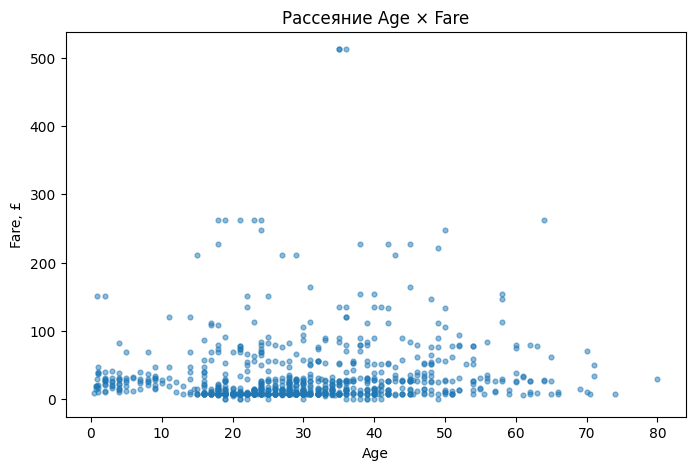

Корреляция Пирсона: 0.112


In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Age'], df['Fare'], alpha=0.5, s=12)
plt.xlabel('Age')
plt.ylabel('Fare, £')
plt.title('Рассеяние Age × Fare')
plt.show()
print('Корреляция Пирсона:', round(df['Age'].corr(df['Fare']), 3))

**Интерпретация:** видимой линейной зависимости нет (корреляция близка к нулю): цена билета определялась классом каюты, а не возрастом; пассажиры любого возраста встречались как в дешёвых, так и в дорогих билетах.

8. Отнормируйте значения признаков «Возраст» и «Цена билета». Выведите на экран полученный датасет.

In [11]:
df_norm = df_no_name.copy()
for col in ['Age', 'Fare']:
    col_min, col_max = df_norm[col].min(), df_norm[col].max()
    df_norm[col] = (df_norm[col] - col_min) / (col_max - col_min)
df_norm.describe().loc[['min', 'max'], ['Age', 'Fare']]

df_norm

,Survived,Pclass,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,male,0.271174,1,0,0.014151
1,1,1,female,0.472229,1,0,0.139136
2,1,3,female,0.321438,0,0,0.015469
3,1,1,female,0.434531,1,0,0.103644
4,0,3,male,0.434531,0,0,0.015713
...,...,...,...,...,...,...,...
882,0,2,male,0.334004,0,0,0.025374
883,1,1,female,0.233476,0,0,0.058556
884,0,3,female,0.082684,1,2,0.045771
885,1,1,male,0.321438,0,0,0.058556


9. Постройте гистограммы распределения пассажиров по полу и по возрасту для каждого класса. Расположите гистограммы одна под другой. Оси абсцисс должны быть одинаковыми.

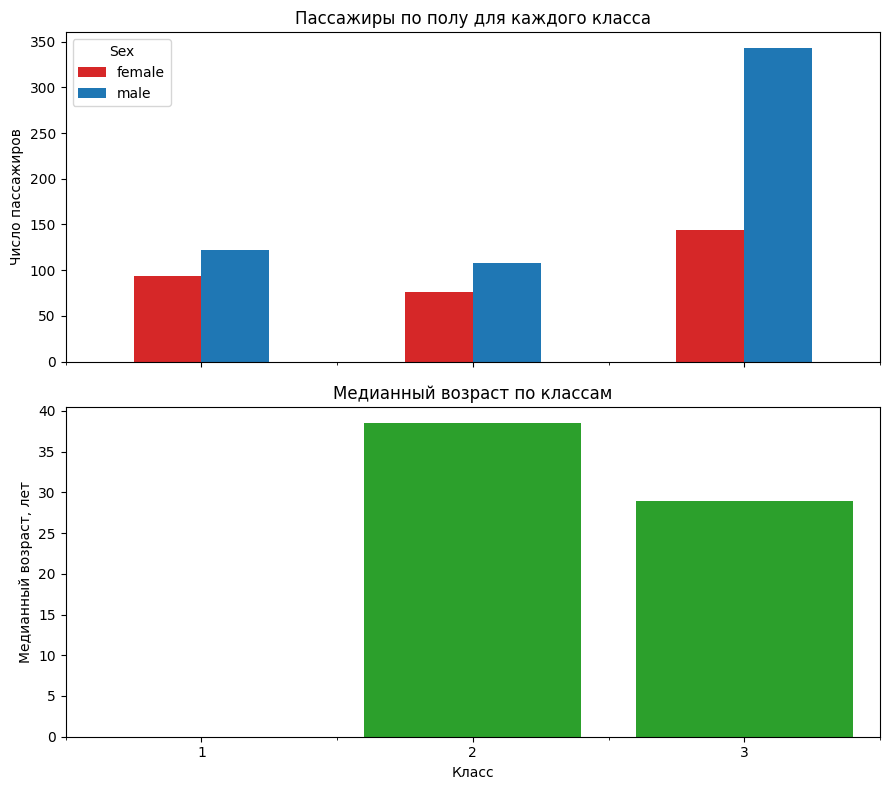

In [12]:
class_counts = df.groupby('Pclass')['Sex'].value_counts().unstack()
age_by_class = df.groupby('Pclass')['Age'].median()

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

class_counts.plot(kind='bar', ax=axes[0], color=['#d62728', '#1f77b4'])
axes[0].set_title('Пассажиры по полу для каждого класса')
axes[0].set_ylabel('Число пассажиров')
axes[0].set_xlabel('')

axes[1].bar(age_by_class.index, age_by_class.values, color='#2ca02c')
axes[1].set_title('Медианный возраст по классам')
axes[1].set_xlabel('Класс')
axes[1].set_ylabel('Медианный возраст, лет')

plt.tight_layout()
plt.show()

**Интерпретация:** большинство пассажиров — третьего класса, где мужчин существенно больше; с ростом класса пассажиры старше (медианный возраст в первом классе заметно выше, чем в третьем, где много молодых мужчин-эмигрантов). Оси абсцисс обоих графиков едины — номера классов 1–3.

10. Сделайте выводы по работе.

## Выводы

В ходе лабораторной работы освоен стек анализа данных Python: DataFrame Pandas загружен из CSV без пропущенных значений; выполнены булевы фильтрации и группировки (подсчёты по варианту и всем подпунктам), оценка выбросов через квартили и IQR, проверка статистических гипотез группировками и корреляцией (билет дороже — выживаемость выше; женщинам выжить было проще; возрастной связи с ценой нет). Произведена предобработка данных под модель машинного обучения: удалён неинформативный признак Name, выполнено one-hot кодирование категориального пола Sex, признаки Age и Fare отнормированы min-max в [0, 1]. Построены гистограмма, boxplot, диаграмма рассеяния и парные столбчатые диаграммы с общей осью абсцисс средствами Matplotlib. Все графики проинтерпретированы.